# 03 — Predictability vs Lead Time

**Questions.** How fast does predictability decay? Does the model ranking
change with lead time — are there crossovers? Which stations degrade fastest?

Metric: MAE in normalised units where stations are compared (removes scale
differences between e.g. mountain and valley wind), physical units otherwise.
Δ=0 excluded from all degradation statistics (reconstruction, not forecasting).

In [8]:
# ── Bootstrap ────────────────────────────────────────────────────────────────
import os, sys
import numpy as np, pandas as pd, matplotlib.pyplot as plt
for _cand in (os.getcwd(),
              os.path.join(os.getcwd(), "notebooks", "analysis"),
              os.path.dirname(os.path.abspath("__file__"))):
    if os.path.isfile(os.path.join(_cand, "common.py")):
        if _cand not in sys.path: sys.path.insert(0, _cand)
        break
import importlib
import common as C
# common.py is edited while these notebooks are open. A plain import is cached
# by the kernel, so edits are invisible until a restart — and a stale module
# silently serves stale caches (this is exactly how a station_table without
# easting/northing survived a fix to station_table). Reload every run.
importlib.reload(C)
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
RUNS = C.discovered_runs()
for r, d in RUNS.items(): print(f"{r:20s} {sorted(d)}")

lstm-baseline-v1     ['mr0.00']
v27                  ['mr0.00', 'mr0.50']
v30-nll              ['mr0.00', 'mr0.50']
v31                  ['mr0.00']
v32-blind            ['mr0.00']


In [9]:
AGG = {(r, mr): C.load_agg(r, mr) for r, mrs in RUNS.items() for mr in mrs}
GRID = AGG[("v27", "mr0.00")]["grid"]; LEAD = C.lead_labels(GRID); K = len(GRID)
MR0 = [(r, "mr0.00") for r in RUNS if "mr0.00" in RUNS[r]]
VARS = C.norm_stats()["var_names"]; stn = C.station_table()

## 1. Degradation relative to +30 min

`MAE(lead) / MAE(+30min)` per model and variable. A ratio of 2 means the error
doubled. Steeper = faster loss of predictability. Baselines shown for
reference: persistence defines the "no-model" decay rate.

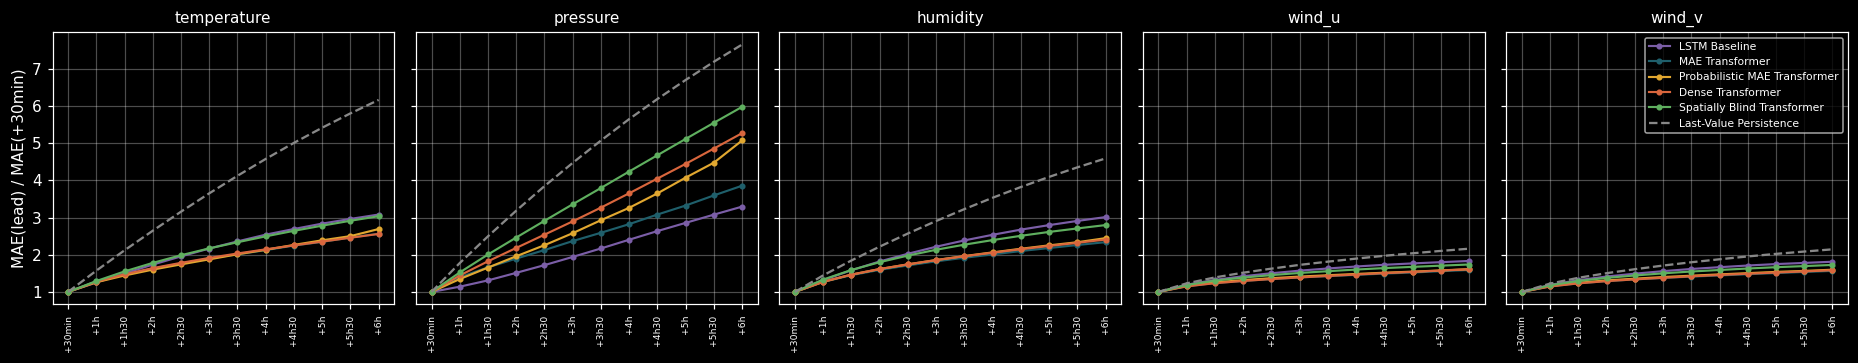

In [10]:
fig, axes = plt.subplots(1, 5, figsize=(17, 3.4), sharey=True)
ref = AGG[("v27", "mr0.00")]
for vi, (ax, v) in enumerate(zip(axes, VARS)):
    for run, mr in MR0:
        m = C.metric(AGG[(run, mr)], "mae", pool=("N",))[:, vi]
        ax.plot(range(1, K), m[1:] / m[1], "o-", ms=3, lw=1.4,
                color=C.MODELS[run][1], label=C.MODELS[run][0])
    p = C.metric(ref, "mae", est="per", pool=("N",))[:, vi]
    ax.plot(range(1, K), p[1:] / p[1], "--", color="#888", label=C.BASELINE_LABELS["persistence"])
    ax.set_title(v, fontsize=10); ax.grid(alpha=.3)
    ax.set_xticks(range(1, K)); ax.set_xticklabels(LEAD[1:], rotation=90, fontsize=6)
axes[0].set_ylabel("MAE(lead) / MAE(+30min)"); axes[-1].legend(fontsize=7)
plt.tight_layout(); C.save_fig(fig, "03_degradation_ratio"); plt.show()

## 2. Does the ranking change with lead time?

Rank of each model (1 = best) per variable × lead, plus a crossover table
listing every (variable, lead) where the leader changes from the previous
lead. Small MAE differences produce rank noise — read jointly with the CI
analysis in notebook 06 before claiming a real crossover.

temperature: leader = Dense Transformer at every lead
pressure: leader = Dense Transformer at every lead
humidity: leader = Dense Transformer at every lead
wind_u: leader changes -> +6h: MAE Transformer
wind_v: leader = Dense Transformer at every lead


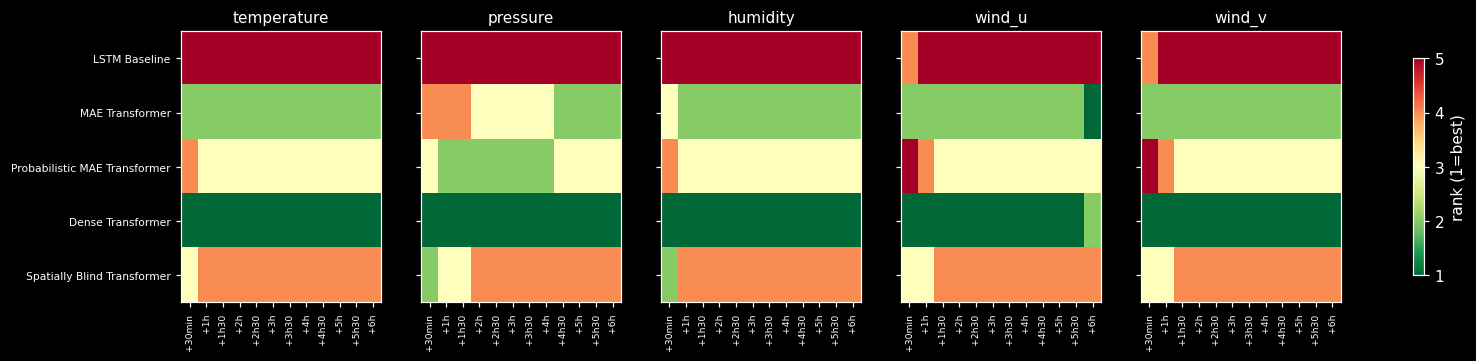

In [11]:
ranks = {}
for vi, v in enumerate(VARS):
    tab = pd.DataFrame(
        {C.MODELS[run][0]: C.metric(AGG[(run, mr)], "mae", pool=("N",))[1:, vi]
         for run, mr in MR0}, index=LEAD[1:])
    ranks[v] = tab.rank(axis=1)
    lead_model = tab.idxmin(axis=1)
    cross = lead_model[lead_model != lead_model.shift()].iloc[1:]
    if len(cross):
        print(f"{v}: leader changes -> " +
              "; ".join(f"{i}: {m}" for i, m in cross.items()))
    else:
        print(f"{v}: leader = {lead_model.iloc[0]} at every lead")
fig, axes = plt.subplots(1, 5, figsize=(17, 3.2), sharey=True)
for ax, v in zip(axes, VARS):
    im = ax.imshow(ranks[v].T.values, aspect="auto", cmap="RdYlGn_r",
                   vmin=1, vmax=len(MR0))
    ax.set_title(v, fontsize=10)
    ax.set_xticks(range(K - 1)); ax.set_xticklabels(LEAD[1:], rotation=90, fontsize=6)
    ax.set_yticks(range(len(MR0)))
    ax.set_yticklabels(ranks[v].columns, fontsize=7)
fig.colorbar(im, ax=axes, label="rank (1=best)", shrink=.8)
C.save_fig(fig, "03_rank_vs_lead"); plt.show()

## 3. Station × lead heatmap — who degrades fastest?

Normalised MAE per station and lead (v27, pooled over variables), stations
sorted by their +6h/+30min degradation ratio. The fastest-degrading stations
are where forecasting (as opposed to nowcasting) is hardest.

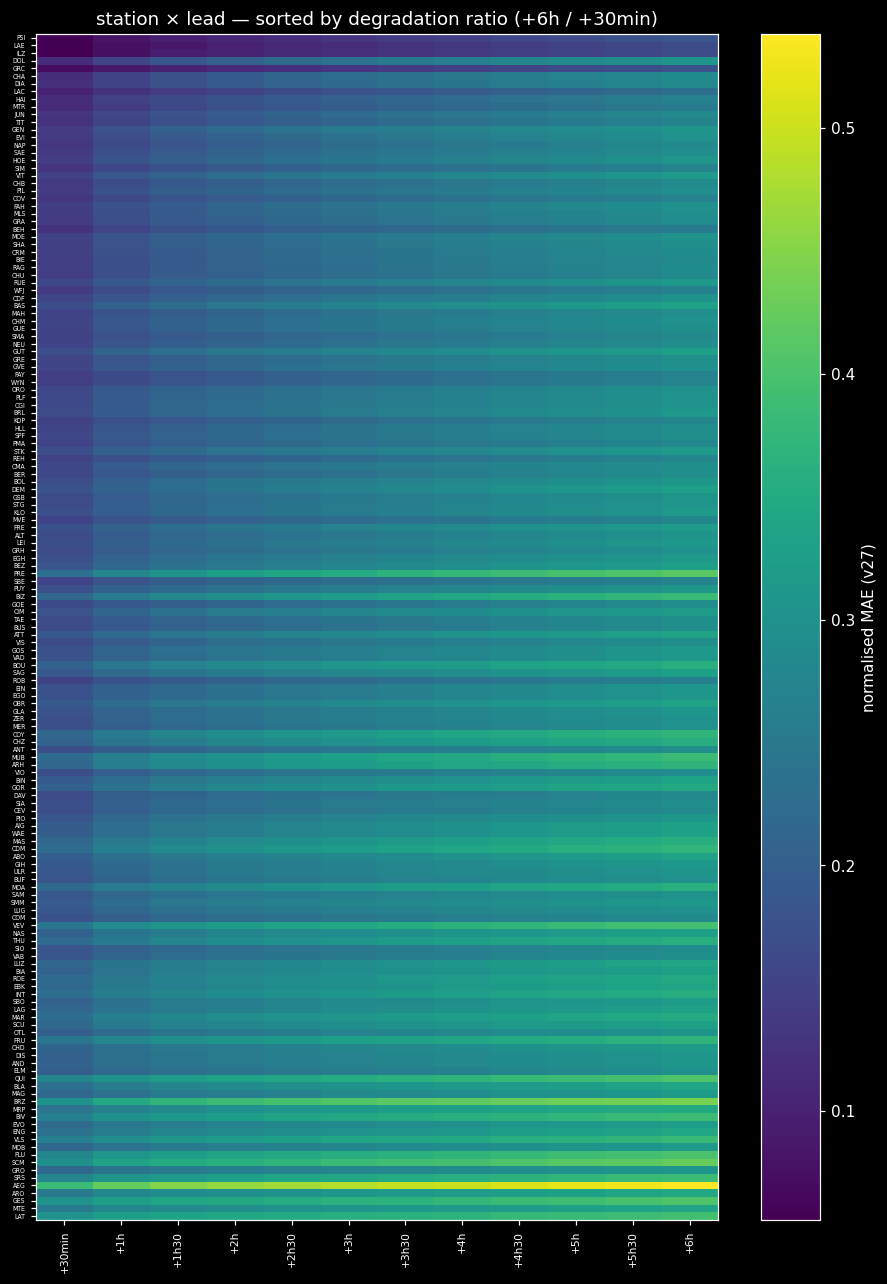

,abbr,degradation_ratio,height_m,nn_dist_km
0,PSI,3.13,334.00,2.36
1,LAE,2.98,844.55,10.46
2,ILZ,2.95,698.00,7.95
3,DOL,2.59,1669.75,10.21
4,GRC,2.51,1605.00,11.97
5,CHA,2.44,1594.20,6.11
6,DIA,2.29,2964.00,10.86
7,LAC,2.28,468.00,8.01
8,HAI,2.24,718.70,3.73
9,MTR,2.23,2171.00,5.55


'/Users/aureliedejong/PycharmProjects/weather-station-model-with-transformers/analysis_outputs/tables/03_fastest_degrading_stations.csv'

In [12]:
a = AGG[("v27", "mr0.00")]
nm = a["mod_all_sum_norm"] / np.maximum(a["mod_all_cnt"], 1)     # (K,N,V)
cnt = a["mod_all_cnt"]
nm_kn = (a["mod_all_sum_norm"].sum(2) / np.maximum(cnt.sum(2), 1))  # (K,N)
ratio = nm_kn[-1] / np.maximum(nm_kn[1], 1e-9)
order = np.argsort(ratio)[::-1]
fig, ax = plt.subplots(figsize=(10, 14))
im = ax.imshow(nm_kn[1:, order].T, aspect="auto", cmap="viridis")
ax.set_xticks(range(K - 1)); ax.set_xticklabels(LEAD[1:], rotation=90, fontsize=7)
ax.set_yticks(range(len(stn)))
ax.set_yticklabels(stn.abbr.values[order], fontsize=4)
fig.colorbar(im, label="normalised MAE (v27)")
ax.set_title("station × lead — sorted by degradation ratio (+6h / +30min)")
C.save_fig(fig, "03_station_lead_heatmap"); plt.show()
top = pd.DataFrame({"abbr": stn.abbr.values[order[:12]],
                    "degradation_ratio": ratio[order[:12]],
                    "height_m": stn.height.values[order[:12]],
                    "nn_dist_km": stn.nn_dist_km.values[order[:12]]})
display(top.round(2)); C.save_table(top, "03_fastest_degrading_stations")

## Interpretation

**How to read.** The degradation panel separates *nowcast difficulty* (level at
+30min) from *forecast difficulty* (slope). Wind decays fastest toward its
station variance (ratio → the persistence curve); pressure decays slowest.

**Observations** (after running): note where the model curves decay more slowly
than persistence — that gap is exactly what the model has learned beyond
carrying the state forward. Check whether fast-degrading stations in §3 are
high-altitude/isolated (table columns height, nn_dist) — that hypothesis is
tested properly in notebook 05.

**Caution.** Rank flips at neighbouring leads with sub-0.01 MAE differences are
noise; confirm any claimed crossover against the bootstrap CIs in notebook 06.

## 4. Shared per-station x lead table

`analysis_outputs/tables/per_station_lead_metrics.csv` holds MAE and RMSE in
**physical units** for every (model, mask ratio, estimator, lead, station,
variable), written by whichever of this suite or
`Test_Results_Exploration.ipynb` runs first. Both use the same column contract,
so the file is interchangeable.

Two consequences: figures can be re-made in a fresh kernel without touching a
2 GB dump, and any station subset can be plotted directly — the accumulators
previously had lead x variable and station x variable separately, never the
two together.

Windows per TOD bin: {'00–06 UTC': 2920, '06–12 UTC': 2921, '12–18 UTC': 2923, '18–24 UTC': 2920}


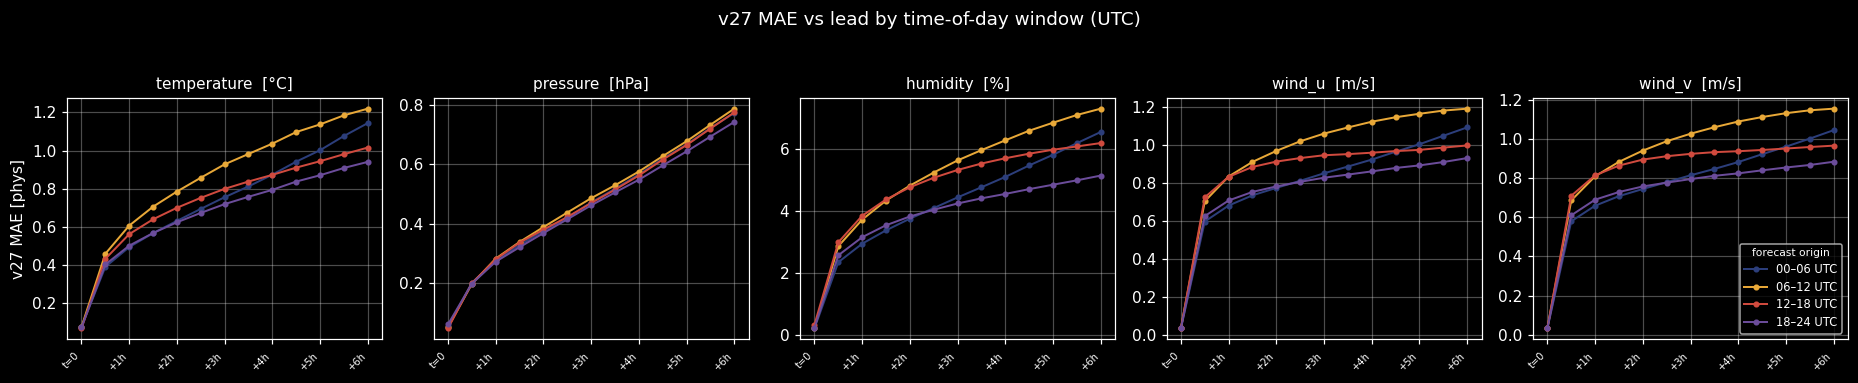

In [14]:
# ── v27 MAE vs lead by time-of-day window ─────────────────────────────────
# The per-station-lead table is aggregated over all windows, so time-of-day
# requires going back to the dump.  We bin by the forecast-origin hour (t0),
# i.e. the END of the 12 h input window, which is the physically meaningful
# reference point.  Hours are UTC; Swiss local time is UTC+1 (CET) / +2 (CEST).

import datetime as _dt

d = C.load_dump("v27", "mr0.00")
ns = C.norm_stats(); _STD = ns["std"]; _KEEP = C.keep_mask(stn, ns["var_names"])

# forecast-origin hour-of-day (UTC) — target_hours[:, 0] is t0
_t0h = d["target_hours"][:, 0].numpy()
_hod = _t0h % 24

TOD_BINS   = [(0, 6), (6, 12), (12, 18), (18, 24)]
TOD_LABELS = ["00–06 UTC", "06–12 UTC", "12–18 UTC", "18–24 UTC"]
TOD_COLORS = ["#2C3E7B", "#E8A838", "#D04A3E", "#6B4C9A"]

_P = d["preds"]                                    # (M, K, N, 5) tensor
_T = d["targets"][:, :, :, :5]                     # (M, K, N, 5) tensor
_M = d["masks"][:, :, :, :5]                       # (M, K, N, 5) tensor
_Kd = _P.shape[1]

# accumulate MAE per TOD bin and lead, pooling over stations and windows
_mae_tod = np.zeros((4, _Kd, 5))
_cnt_tod = np.zeros((4, _Kd, 5))
for _ti, (_lo, _hi) in enumerate(TOD_BINS):
    _sel = np.where((_hod >= _lo) & (_hod < _hi))[0]
    _p = _P[_sel].numpy().astype(np.float64)
    _t = _T[_sel].numpy().astype(np.float64)
    _m = (_M[_sel].numpy() > 0.5) & _KEEP[None, None]
    _ep = np.abs(_p - _t) * _STD[None, None]       # physical units
    _mae_tod[_ti] = (_ep * _m).sum(axis=(0, 2))     # (K, V)
    _cnt_tod[_ti] = _m.sum(axis=(0, 2))
    del _p, _t, _m, _ep
_mae_tod = np.where(_cnt_tod > 0, _mae_tod / _cnt_tod, np.nan)

print("Windows per TOD bin:",
      {l: int(np.sum((_hod >= lo) & (_hod < hi)))
       for (lo, hi), l in zip(TOD_BINS, TOD_LABELS)})
del d  # free ~2 GB

fig, axes = plt.subplots(1, 5, figsize=(17, 3.3))
for ax, (vi, v) in zip(axes, enumerate(VARS)):
    for ti, (label, col) in enumerate(zip(TOD_LABELS, TOD_COLORS)):
        ax.plot(range(_Kd), _mae_tod[ti, :, vi],
                "o-", ms=3, lw=1.3, color=col, label=label)
    ax.set_xticks(range(0, len(LEAD), 2))
    ax.set_xticklabels(LEAD[::2], rotation=45, ha="right", fontsize=6.5)
    ax.set_title(f"{v}  [{C.UNITS[v]}]", fontsize=10); ax.grid(alpha=.3)
axes[0].set_ylabel("v27 MAE [phys]")
axes[-1].legend(fontsize=7.5, title="forecast origin", title_fontsize=7)
fig.suptitle("v27 MAE vs lead by time-of-day window (UTC)", y=1.04)
plt.tight_layout(); C.save_fig(fig, "03_lead_by_tod"); plt.show()
